# Clasificación de Piso en el Dataset UJIIndoorLoc usando Redes Neuronales Artificiales (ANN)

---

## Introducción

En este notebook se replica el flujo de análisis implementado previamente para la clasificación del **piso** en un entorno interior utilizando el dataset **UJIIndoorLoc**, pero en esta ocasión aplicando un modelo de **red neuronal artificial** con capas completamente conectadas (Fully Connected – FC).

El conjunto de datos UJIIndoorLoc contiene mediciones de señales WiFi tomadas en diferentes ubicaciones dentro de un edificio, junto con información asociada como coordenadas, piso, usuario y timestamp. Nuestro objetivo sigue siendo predecir el **piso** en el que se encuentra un dispositivo, tratando el problema como una clasificación multiclase (planta baja, primer piso, segundo piso, etc.).

## Objetivos

- **Cargar y explorar** el conjunto de datos UJIIndoorLoc.
- **Preparar** los datos seleccionando las características relevantes y la variable objetivo (`FLOOR`).
- **Dividir** el dataset en entrenamiento y validación (80/20).
- **Construir** una red neuronal totalmente conectada (fully connected ANN) para clasificar el piso.
- **Diseñar y ajustar** la arquitectura de la red (número de capas, unidades por capa, funciones de activación, etc.).
- **Evaluar el desempeño** del modelo en el conjunto de validación mediante métricas como *accuracy*, *precision*, *recall*, y *F1-score*.
- **Comparar los resultados** obtenidos con los modelos clásicos de clasificación entrenados anteriormente.

Este ejercicio permite evaluar la capacidad de generalización de una red neuronal densa sobre datos del mundo real, comparando su desempeño con algoritmos tradicionales y practicando buenas prácticas en diseño, entrenamiento y evaluación de modelos neuronales.

---


## Descripción del Dataset

El dataset utilizado en este análisis es el **UJIIndoorLoc Dataset**, ampliamente utilizado para tareas de localización en interiores a partir de señales WiFi. Está disponible públicamente en la UCI Machine Learning Repository y ha sido recopilado en un entorno real de un edificio universitario.

Cada muestra corresponde a una observación realizada por un dispositivo móvil, donde se registran las intensidades de señal (RSSI) de más de 500 puntos de acceso WiFi disponibles en el entorno. Además, cada fila contiene información contextual como la ubicación real del dispositivo (coordenadas X e Y), el piso, el edificio, el identificador del usuario, y la marca temporal.

El objetivo en esta tarea es predecir el **piso** (`FLOOR`) en el que se encontraba el dispositivo en el momento de la medición, considerando únicamente las características numéricas provenientes de las señales WiFi.

### Estructura del dataset

- **Número de muestras**: ~20,000
- **Número de características**: 520
  - 520 columnas con valores de intensidad de señal WiFi (`WAP001` a `WAP520`)
- **Variable objetivo**: `FLOOR` (variable categórica con múltiples clases, usualmente entre 0 y 4)

### Columnas relevantes

- `WAP001`, `WAP002`, ..., `WAP520`: niveles de señal recibida desde cada punto de acceso WiFi (valores entre -104 y 0, o 100 si no se detectó).
- `FLOOR`: clase objetivo a predecir (nivel del edificio).
- (Otras columnas como `BUILDINGID`, `SPACEID`, `USERID`, `TIMESTAMP`, etc., pueden ser ignoradas o utilizadas en análisis complementarios).

### Contexto del problema

La localización en interiores es un problema complejo en el que tecnologías como el GPS no funcionan adecuadamente. Los sistemas basados en WiFi han demostrado ser una alternativa efectiva para estimar la ubicación de usuarios en edificios. Poder predecir automáticamente el piso en el que se encuentra una persona puede mejorar aplicaciones de navegación en interiores, accesibilidad, gestión de emergencias y servicios personalizados. Este tipo de problemas es típicamente abordado mediante algoritmos de clasificación multiclase.


### Estrategia de evaluación

En este análisis seguiremos una metodología rigurosa para garantizar la validez de los resultados:

1. **Dataset de entrenamiento**: Se utilizará exclusivamente para el desarrollo, entrenamiento y optimización de hiperparámetros de todos los modelos. Este conjunto será dividido internamente en subconjuntos de entrenamiento y validación (80/20) para la selección de hiperparámetros mediante validación cruzada.

2. **Dataset de prueba**: Se reservará únicamente para la **evaluación final** de los modelos ya optimizados. Este conjunto **no debe ser utilizado** durante el proceso de selección de hiperparámetros, ajuste de modelos o toma de decisiones sobre la arquitectura, ya que esto introduciría sesgo y comprometería la capacidad de generalización estimada.

3. **Validación cruzada**: Para la optimización de hiperparámetros se empleará validación cruzada 5-fold sobre el conjunto de entrenamiento, lo que permitirá una estimación robusta del rendimiento sin contaminar los datos de prueba.

Esta separación estricta entre datos de desarrollo y evaluación final es fundamental para obtener una estimación realista del rendimiento que los modelos tendrían en un escenario de producción con datos completamente nuevos.

---


In [3]:
# === Celda 0: Setup / Configuración base ===
from pathlib import Path
import numpy as np
import pandas as pd

# Semilla global (reproducibilidad)
SEED = 42
rng = np.random.default_rng(SEED)

# Rutas (ajustadas a tu estructura)
DATA_DIR   = Path(r"C:\IA_RigobertoZelayandia\CLase-IA\PROYECTO FINAL\dataset")
TRAIN_PATH = DATA_DIR / "trainingData.csv"
VALID_PATH = DATA_DIR / "validationData.csv"

print("TRAIN_PATH:", TRAIN_PATH)
print("VALID_PATH:", VALID_PATH)
print("Existencia -> train:", TRAIN_PATH.exists(), "| valid:", VALID_PATH.exists())


TRAIN_PATH: C:\IA_RigobertoZelayandia\CLase-IA\PROYECTO FINAL\dataset\trainingData.csv
VALID_PATH: C:\IA_RigobertoZelayandia\CLase-IA\PROYECTO FINAL\dataset\validationData.csv
Existencia -> train: True | valid: True


## Paso 1: Cargar y explorar el dataset

**Instrucciones:**
- Descarga el dataset **UJIIndoorLoc** desde la UCI Machine Learning Repository o utiliza la versión proporcionada en el repositorio del curso (por ejemplo: `datasets\UJIIndoorLoc\trainingData.csv`).
- Carga el dataset utilizando `pandas`.
- Muestra las primeras filas del dataset utilizando `df.head()`.
- Imprime el número total de muestras (filas) y características (columnas).
- Verifica cuántas clases distintas hay en la variable objetivo `FLOOR` y cuántas muestras tiene cada clase (`df['FLOOR'].value_counts()`).


In [4]:
# === PASO 1: Cargar y explorar el dataset (solo TRAIN) ===
import pandas as pd

# 1) Carga (solo datos de entrenamiento / desarrollo)
df = pd.read_csv(TRAIN_PATH)

# 2) Vista rápida
display(df.head())

# 3) Tamaños
n_filas, n_cols = df.shape
print(f"Shape (filas, columnas): {df.shape}")

# 4) Info de columnas y tipos (opcional, pero útil)
print("\nTipos de datos (primeras columnas):")
print(df.dtypes.head(10))

# 5) Clases de la variable objetivo FLOOR
if "FLOOR" not in df.columns:
    raise ValueError("No se encontró la columna 'FLOOR' en el dataset de entrenamiento.")

vc = df["FLOOR"].value_counts().sort_index()
print("\nClases distintas en FLOOR:", sorted(df["FLOOR"].unique()))
print("\nConteo por clase (FLOOR):")
print(vc)

print("\nDistribución porcentual por clase (FLOOR):")
print((vc / vc.sum() * 100).round(2).astype(str) + "%")

# --- Nota importante (recordatorio) ---
print("\n[AVISO] El archivo 'validationData.csv' se usará SOLO para la evaluación final.\n"
      "No se usará en ajuste de hiperparámetros ni decisiones de modelo.")


,WAP001,WAP002,WAP003,WAP004,WAP005,WAP006,WAP007,WAP008,WAP009,WAP010,...,WAP520,LONGITUDE,LATITUDE,FLOOR,BUILDINGID,SPACEID,RELATIVEPOSITION,USERID,PHONEID,TIMESTAMP
0,100,100,100,100,100,100,100,100,100,100,...,100,-7541.2643,4.864921e+06,2,1,106,2,2,23,1371713733
1,100,100,100,100,100,100,100,100,100,100,...,100,-7536.6212,4.864934e+06,2,1,106,2,2,23,1371713691
2,100,100,100,100,100,100,100,-97,100,100,...,100,-7519.1524,4.864950e+06,2,1,103,2,2,23,1371714095
3,100,100,100,100,100,100,100,100,100,100,...,100,-7524.5704,4.864934e+06,2,1,102,2,2,23,1371713807
4,100,100,100,100,100,100,100,100,100,100,...,100,-7632.1436,4.864982e+06,0,0,122,2,11,13,1369909710


Shape (filas, columnas): (19937, 529)

Tipos de datos (primeras columnas):
WAP001    int64
WAP002    int64
WAP003    int64
WAP004    int64
WAP005    int64
WAP006    int64
WAP007    int64
WAP008    int64
WAP009    int64
WAP010    int64
dtype: object

Clases distintas en FLOOR: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Conteo por clase (FLOOR):
FLOOR
0    4369
1    5002
2    4416
3    5048
4    1102
Name: count, dtype: int64

Distribución porcentual por clase (FLOOR):
FLOOR
0    21.91%
1    25.09%
2    22.15%
3    25.32%
4     5.53%
Name: count, dtype: object

[AVISO] El archivo 'validationData.csv' se usará SOLO para la evaluación final.
No se usará en ajuste de hiperparámetros ni decisiones de modelo.


---

## Paso 2: Preparar los datos

**Instrucciones:**

- Elimina las columnas que no son relevantes para la tarea de clasificación del piso:
  - `LONGITUDE`, `LATITUDE`, `SPACEID`, `RELATIVEPOSITION`, `USERID`, `PHONEID`, `TIMESTAMP`
- Conserva únicamente:
  - Las columnas `WAP001` a `WAP520` como características (RSSI de puntos de acceso WiFi).
  - La columna `FLOOR` como variable objetivo.
- Verifica si existen valores atípicos o valores inválidos en las señales WiFi (por ejemplo: valores constantes como 100 o -110 que suelen indicar ausencia de señal).
- Separa el conjunto de datos en:
  - `X`: matriz de características (todas las columnas `WAP`)
  - `y`: vector objetivo (`FLOOR`)


In [5]:
import numpy as np
import pandas as pd
import re

# 0) Comprobar que 'df' existe (del Paso 1, TRAIN cargado)
assert 'df' in globals(), "Primero ejecuta el Paso 1 para cargar el dataset de entrenamiento en 'df'."

# 1) Columnas no relevantes (si alguna no existe, se ignora sin error)
DROP_COLS = ['LONGITUDE','LATITUDE','SPACEID','RELATIVEPOSITION','USERID','PHONEID','TIMESTAMP']
df2 = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors='ignore')

# 2) Detectar columnas WAP: nombres tipo WAP001..WAP520
WAP_COLS = sorted([c for c in df2.columns if re.fullmatch(r"WAP\d{3}", c)])
if not WAP_COLS:
    raise ValueError("No se encontraron columnas WAP (patrón WAP###) en el dataset.")

# 3) Asegurar que FLOOR existe y es entero
if "FLOOR" not in df2.columns:
    raise ValueError("No se encontró la columna 'FLOOR' en el dataset de entrenamiento.")
y = df2["FLOOR"].astype(int)

# 4) Asegurar numéricos en WAPs (si hubiera strings, se fuerzan; valores no convertibles -> NaN)
df2[WAP_COLS] = df2[WAP_COLS].apply(pd.to_numeric, errors="coerce")

# 5) Separar matriz de características X (solo WAPs)
X = df2[WAP_COLS].copy()

print(f"Total de WAPs seleccionadas: {len(WAP_COLS)}")
print(f"Shape X: {X.shape} | Shape y: {y.shape}")

# 6) Revisión de valores típicos de ausencia/ruido en señal
total_vals = X.size
cnt_100   = np.sum(X.values == 100)     # convención muy usada para "sin señal"
cnt_m110  = np.sum(X.values == -110)    # otra convención posible
cnt_nan   = np.isnan(X.values).sum()

print("\n--- Chequeo de valores 'inválidos' o marcadores de ausencia de señal ---")
print(f"Valores 100   : {cnt_100:,}  ({cnt_100/total_vals:.2%})")
print(f"Valores -110  : {cnt_m110:,}  ({cnt_m110/total_vals:.2%})")
print(f"Valores NaN   : {cnt_nan:,}   ({cnt_nan/total_vals:.2%})")

# 7) Top 10 WAP con mayor proporción de (100, -110 o NaN)
ratio_invalid = ((X == 100) | (X == -110) | X.isna()).mean()
top_bad = ratio_invalid.sort_values(ascending=False).head(10).to_frame("ratio_invalid")
print("\nTop 10 WAP con mayor proporción de valores inválidos:")
display(top_bad.style.format({"ratio_invalid": "{:.2%}"}))

# 8) Guardar copias para siguientes pasos
X_train_raw = X.copy()   # versión "cruda" para paso 3 (mapeo 100 -> -100)
y_train     = y.copy()




Total de WAPs seleccionadas: 520
Shape X: (19937, 520) | Shape y: (19937,)

--- Chequeo de valores 'inválidos' o marcadores de ausencia de señal ---
Valores 100   : 10,008,477  (96.54%)
Valores -110  : 0  (0.00%)
Valores NaN   : 0   (0.00%)

Top 10 WAP con mayor proporción de valores inválidos:


,ratio_invalid
WAP520,100.00%
WAP497,100.00%
WAP491,100.00%
WAP487,100.00%
WAP488,100.00%
WAP485,100.00%
WAP482,100.00%
WAP247,100.00%
WAP451,100.00%
WAP458,100.00%


--- 

## Paso 3: Preprocesamiento de las señales WiFi

**Contexto:**

Las columnas `WAP001` a `WAP520` representan la intensidad de la señal (RSSI) recibida desde distintos puntos de acceso WiFi. Los valores típicos de RSSI están en una escala negativa, donde:

- Valores cercanos a **0 dBm** indican señal fuerte.
- Valores cercanos a **-100 dBm** indican señal débil o casi ausente.
- Un valor de **100** en este dataset representa una señal **no detectada**, es decir, el punto de acceso no fue visto por el dispositivo en ese instante.

**Instrucciones:**

- Para facilitar el procesamiento y tratar la ausencia de señal de forma coherente, se recomienda mapear todos los valores **100** a **-100**, que semánticamente representa *ausencia de señal detectable*.
- Esto unifica el rango de valores y evita que 100 (un valor artificial) afecte negativamente la escala de los algoritmos.

**Pasos sugeridos:**

- Reemplaza todos los valores `100` por `-100` en las columnas `WAP001` a `WAP520`:
  ```python
  X[X == 100] = -100


In [6]:
# === PASO 3: Preprocesamiento de señales (solo TRAIN) ===

import numpy as np
import pandas as pd

def preprocess_wifi(X, fill_missing_with=-110):
    Xp = X.copy()
    # 1) Mapear 100 -> -100
    Xp = Xp.replace(100, -100)
    # 2) (Opcional) Imputar NaN si hubiesen
    if fill_missing_with is not None:
        Xp = Xp.fillna(fill_missing_with)
    # 3) (Opcional) Limitar a un rango típico [-110, 0] para evitar outliers raros
    Xp = Xp.clip(lower=-110, upper=0)
    return Xp

# Comprobación de que venimos del Paso 2
assert 'X_train_raw' in globals() and 'y_train' in globals(), \
       "Primero ejecuta el Paso 2 (X_train_raw, y_train)."

# --- conteo antes ---
total_vals = X_train_raw.size
cnt_100   = np.sum(X_train_raw.values == 100)
cnt_m110  = np.sum(X_train_raw.values == -110)
cnt_nan   = np.isnan(X_train_raw.values).sum()
print("[ANTES] 100:", cnt_100, "| -110:", cnt_m110, "| NaN:", cnt_nan, f"| total={total_vals}")

# Procesar
X_train = preprocess_wifi(X_train_raw, fill_missing_with=-110)

# --- conteo después ---
total_vals2 = X_train.size
cnt_100_2   = np.sum(X_train.values == 100)
cnt_m100_2  = np.sum(X_train.values == -100)
cnt_m110_2  = np.sum(X_train.values == -110)
cnt_nan_2   = np.isnan(X_train.values).sum()

print("[DESPUÉS] 100:", cnt_100_2,
      "| -100:", cnt_m100_2,
      "| -110:", cnt_m110_2,
      "| NaN:", cnt_nan_2,
      f"| total={total_vals2}")



[ANTES] 100: 10008477 | -110: 0 | NaN: 0 | total=10367240
[DESPUÉS] 100: 0 | -100: 10008716 | -110: 0 | NaN: 0 | total=10367240


---

## Paso 4: Preparación del dataset

**Objetivo:**

Diseñar una función que cargue el dataset **UJIIndoorLoc**, realice limpieza básica si es necesario, normalice las variables predictoras, y divida los datos en tres subconjuntos de forma estratificada para su uso en redes neuronales.

**Esquema de partición:**

1. **20% del dataset se reserva como conjunto de testeo final.**
2. **El 80% restante se subdivide en:**
   - **80% para entrenamiento** → equivale al 64% del total.
   - **20% para validación** → equivale al 16% del total.

  En este caso, ya existe un conjunto de testeo definido por separado. Por lo tanto, la función solo debe dividir el dataset de entrenamiento original en dos subconjuntos estratificados:

  - **80% para entrenamiento**
  - **20% para validación**

**Requisitos de la función:**

- La función debe realizar las siguientes tareas:
  1. Cargar el archivo `.csv` del dataset.
  2. Seleccionar las columnas de entrada (features) y la variable objetivo (`FLOOR`).
  3. Aplicar normalización a las variables predictoras utilizando `MinMaxScaler` para que todos los valores queden entre 0 y 1.
  4. Realizar las divisiones del conjunto de datos en el orden indicado, asegurando estratificación según la variable objetivo.
  
- La función debe recibir como parámetros:
  - La ruta al archivo `.csv` del dataset.
  - El nombre de la columna objetivo (por ejemplo, `FLOOR`).
  - Un parámetro `random_state` para asegurar reproducibilidad de las divisiones.

- La función debe retornar:
  - `X_train`, `X_val`, `X_test`: subconjuntos de características normalizadas.
  - `y_train`, `y_val`, `y_test`: subconjuntos de etiquetas, codificadas si es necesario para clasificación multiclase.

**Nota:** Esta función es fundamental para garantizar un flujo de entrenamiento robusto y reproducible en redes neuronales.


In [9]:
# === PASO 4: Entrenamiento + Optimización (solo con TRAIN) ===
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Comprobación de que venimos del paso 3
assert 'X_train' in globals() and 'y_train' in globals(), \
       "Primero ejecuta los pasos 1–3 para tener X_train e y_train."

SEED = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

results = []
best_models = {}

def run_grid(name, pipe, param_grid, scoring='accuracy', cv=cv):
    """Helper: entrena GridSearchCV, guarda mejor CV y el mejor estimador."""
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        verbose=0
    )
    gs.fit(X_train, y_train)
    print(f"{name:12s} | best_cv={gs.best_score_:.4f} | params={gs.best_params_}")
    results.append({
        "modelo": name,
        "best_cv": gs.best_score_,
        "best_params": gs.best_params_,
        "best_estimator": gs.best_estimator_
    })
    best_models[name] = gs.best_estimator_
    return gs

# ---------- KNN ----------
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier())
])
param_grid = {
    "clf__n_neighbors": [3, 5, 7, 9],
    "clf__weights": ["uniform", "distance"],
    "clf__p": [1, 2],  # Manhattan / Euclídea
}
gs_knn = run_grid("KNN", pipe, param_grid)

# ---------- Gaussian Naive Bayes ----------
pipe = Pipeline([
    ("clf", GaussianNB())
])
param_grid = {
    "clf__var_smoothing": [1e-9, 1e-8, 1e-7]
}
gs_gnb = run_grid("GaussianNB", pipe, param_grid)

# ---------- Regresión Logística ----------
# Nota: lbfgs funciona bien con multiclase; escalado en pipeline.
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED))
])
param_grid = {
    "clf__C": [0.1, 1.0, 10.0],
    "clf__solver": ["lbfgs"],  # estable para multiclase
}
gs_lr = run_grid("LogReg", pipe, param_grid)

# ---------- Árbol de Decisión ----------
pipe = Pipeline([
    ("clf", DecisionTreeClassifier(random_state=SEED))
])
param_grid = {
    "clf__max_depth": [10, 20, 30, None],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 5],
}
gs_dt = run_grid("DecisionTree", pipe, param_grid)

# ---------- SVM (RBF) ----------
# SVM suele ser costoso; grid compacto + escalado.
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", cache_size=1000, random_state=SEED))
])
param_grid = {
    "clf__C": [1, 10, 100],
    "clf__gamma": ["scale", 0.01, 0.001],
}
gs_svm = run_grid("SVM (rbf)", pipe, param_grid)

# ---------- Random Forest ----------
pipe = Pipeline([
    ("clf", RandomForestClassifier(
        random_state=SEED, n_jobs=-1
    ))
])
param_grid = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [None, 20, 40],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2],
}
gs_rf = run_grid("RandomForest", pipe, param_grid)

# ---------- Resumen ordenado por mejor CV ----------
summary = (
    pd.DataFrame([{k: v for k, v in r.items() if k != "best_estimator"} for r in results])
    .sort_values("best_cv", ascending=False)
    .reset_index(drop=True)
)
display(summary)

print("\n[OK] Paso 4 completado. 'best_models' contiene los mejores estimadores por modelo.")


KNN          | best_cv=0.9954 | params={'clf__n_neighbors': 3, 'clf__p': 1, 'clf__weights': 'distance'}
GaussianNB   | best_cv=0.5830 | params={'clf__var_smoothing': 1e-07}
LogReg       | best_cv=0.9933 | params={'clf__C': 1.0, 'clf__solver': 'lbfgs'}
DecisionTree | best_cv=0.9720 | params={'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}
SVM (rbf)    | best_cv=0.9940 | params={'clf__C': 10, 'clf__gamma': 0.001}
RandomForest | best_cv=0.9966 | params={'clf__max_depth': 40, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 400}


,modelo,best_cv,best_params
0,RandomForest,0.996589,"{'clf__max_depth': 40, 'clf__min_samples_leaf'..."
1,KNN,0.995436,"{'clf__n_neighbors': 3, 'clf__p': 1, 'clf__wei..."
2,SVM (rbf),0.993981,"{'clf__C': 10, 'clf__gamma': 0.001}"
3,LogReg,0.993329,"{'clf__C': 1.0, 'clf__solver': 'lbfgs'}"
4,DecisionTree,0.972012,"{'clf__max_depth': None, 'clf__min_samples_lea..."
5,GaussianNB,0.582986,{'clf__var_smoothing': 1e-07}



[OK] Paso 4 completado. 'best_models' contiene los mejores estimadores por modelo.


---
## Paso 5: Entrenamiento de redes neuronales artificiales (ANN)

**Objetivo:**

Entrenar y comparar el rendimiento de diferentes arquitecturas de redes neuronales totalmente conectadas (**Fully Connected ANN**) utilizando **PyTorch** para predecir el piso (`FLOOR`) en el dataset UJIIndoorLoc. El objetivo es observar el impacto de la profundidad y la expansión/compresión de capas sobre el rendimiento del modelo.

**Entorno y configuración:**

- **Framework:** PyTorch
- **Función de pérdida:** `nn.CrossEntropyLoss()`  
  > Esta función es equivalente a `sparse_categorical_crossentropy`, por lo que **no es necesario one-hot encoding** en las etiquetas.
- **Optimizador:** `torch.optim.Adam`
- **Activación:** `ReLU` en todas las capas ocultas
- **Salida:** `Softmax` (implícito en `CrossEntropyLoss`)
- **Épocas:** 20
- **Batch size: 32**
- **Sin Dropout ni BatchNormalization**


### Arquitecturas a evaluar

1. **Arquitectura 1: Compacta**
   ```text
   Input (520)
   → Linear(128) + ReLU
   → Linear(4)
   ```

2. **Arquitectura 2: Dos capas ocultas**
   ```text
   Input (520)
   → Linear(256) + ReLU
   → Linear(128) + ReLU
   → Linear(4)
   ```

3. **Arquitectura 3: Tres capas ocultas**
   ```text
   Input (520)
   → Linear(256) + ReLU
   → Linear(128) + ReLU
   → Linear(64) + ReLU
   → Linear(4)
   ```

4. **Arquitectura 4: Pirámide profunda**
   ```text
   Input (520)
   → Linear(512) + ReLU
   → Linear(256) + ReLU
   → Linear(128) + ReLU
   → Linear(64)  + ReLU
   → Linear(4)
   ```

5. **Arquitectura 5: Expansiva y luego compresiva**
   ```text
   Input (520)
   → Linear(1024) + ReLU
   → Linear(512)  + ReLU
   → Linear(256)  + ReLU
   → Linear(128)  + ReLU
   → Linear(64)   + ReLU
   → Linear(4)
   ```


### Instrucciones

- Implementa cada arquitectura como una subclase de `nn.Module` en PyTorch.
- Entrena durante **20 épocas**, utilizando el conjunto de entrenamiento (`X_train`, `y_train`) y validación (`X_val`, `y_val`).
- Registra la **pérdida de entrenamiento y validación** por época en un gráfico.
- Grafica la evolución de la pérdida para analizar tendencias de aprendizaje, sobreajuste o subajuste.
- Evalúa el modelo final con el conjunto de test (`X_test`, `y_test`) y reporta:
  - **Accuracy**
  - **Precision**
  - **Recall**
  - **F1-score**

5.1 — Setup PyTorch + split train/val (desde X_train, y_train del Paso 3)

In [10]:
# 5.1 — Setup PyTorch + split train/val
import torch, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Tomamos lo ya preparado en el Paso 3
assert 'X_train' in globals() and 'y_train' in globals(), "Ejecuta antes los pasos 1–3 (X_train, y_train)."

# Split 80/20 para train/val (estratificado por FLOOR)
X_tr_nn, X_val_nn, y_tr_nn, y_val_nn = train_test_split(
    X_train.values, y_train.values, test_size=0.2, random_state=SEED, stratify=y_train
)

# Escalado (fit SOLO en train; se aplicará luego también al test)
scaler = StandardScaler().fit(X_tr_nn)
X_tr_nn  = scaler.transform(X_tr_nn)
X_val_nn = scaler.transform(X_val_nn)

# Shapes y n_clases dinámico
N_INPUT   = X_tr_nn.shape[1]   # debería ser 520
N_CLASSES = int(np.unique(y_train).shape[0])  # p.ej. 4

print(f"N_INPUT={N_INPUT} | N_CLASSES={N_CLASSES}")


N_INPUT=520 | N_CLASSES=5


In [24]:
# 5.A — Helpers y timer para entrenamiento
import time
import torch
import torch.nn as nn

# Guarda aquí los tiempos por arquitectura
train_times = {}

@torch.no_grad()
def eval_loss(model, loader, device="cpu"):
    crit = nn.CrossEntropyLoss()
    model.eval()
    tot_loss, tot_n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        loss = crit(out, yb)
        tot_loss += loss.item() * len(xb)
        tot_n += len(xb)
    return tot_loss / max(tot_n, 1)

def train_ann(name, model, train_loader, val_loader, epochs=20, lr=1e-3, device="cpu", verbose=False):
    """
    Entrena un modelo PyTorch y guarda el tiempo total en `train_times[name]`.
    Devuelve el modelo ya entrenado.
    """
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()

    t0 = time.time()
    for ep in range(1, epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            out = model(xb)
            loss = crit(out, yb)
            loss.backward()
            opt.step()

        if verbose:
            tr_loss = eval_loss(model, train_loader, device=device)
            va_loss = eval_loss(model, val_loader, device=device)
            print(f"[{name}] Epoch {ep:02d}/{epochs} | train_loss={tr_loss:.4f} | val_loss={va_loss:.4f}")

    elapsed = time.time() - t0
    train_times[name] = elapsed
    return model


5.2 — DataLoaders (batch=32)

In [11]:
# 5.2 — DataLoaders (batch=32)
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Xtr_t = torch.tensor(X_tr_nn,  dtype=torch.float32)
ytr_t = torch.tensor(y_tr_nn,  dtype=torch.long)
Xva_t = torch.tensor(X_val_nn, dtype=torch.float32)
yva_t = torch.tensor(y_val_nn, dtype=torch.long)

train_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(Xva_t, yva_t), batch_size=BATCH_SIZE, shuffle=False)


Device: cpu


5.3 — Definición de las 5 arquitecturas (sin Dropout ni BatchNorm)

In [14]:
# 5.3 — Modelos ANN
import torch.nn as nn

def fc(in_f, out_f):  # helper
    return nn.Linear(in_f, out_f)

class ANN1_Compacta(nn.Module):
    """Input→128→ReLU→out"""
    def __init__(self, n_in, n_out):
        super().__init__()
        self.net = nn.Sequential(
            fc(n_in, 128), nn.ReLU(),
            fc(128, n_out)
        )
    def forward(self, x): return self.net(x)

class ANN2_DosCapas(nn.Module):
    """Input→256→ReLU→128→ReLU→out"""
    def __init__(self, n_in, n_out):
        super().__init__()
        self.net = nn.Sequential(
            fc(n_in, 256), nn.ReLU(),
            fc(256, 128),  nn.ReLU(),
            fc(128, n_out)
        )
    def forward(self, x): return self.net(x)

class ANN3_TresCapas(nn.Module):
    """Input→256→ReLU→128→ReLU→64→ReLU→out"""
    def __init__(self, n_in, n_out):
        super().__init__()
        self.net = nn.Sequential(
            fc(n_in, 256), nn.ReLU(),
            fc(256, 128),  nn.ReLU(),
            fc(128, 64),   nn.ReLU(),
            fc(64, n_out)
        )
    def forward(self, x): return self.net(x)

class ANN4_Piramide(nn.Module):
    """Input→512→ReLU→256→ReLU→128→ReLU→64→ReLU→out"""
    def __init__(self, n_in, n_out):
        super().__init__()
        self.net = nn.Sequential(
            fc(n_in, 512), nn.ReLU(),
            fc(512, 256),  nn.ReLU(),
            fc(256, 128),  nn.ReLU(),
            fc(128, 64),   nn.ReLU(),
            fc(64, n_out)
        )
    def forward(self, x): return self.net(x)

class ANN5_ExpComp(nn.Module):
    """Input→1024→512→256→128→64→out (todas ReLU)"""
    def __init__(self, n_in, n_out):
        super().__init__()
        self.net = nn.Sequential(
            fc(n_in, 1024), nn.ReLU(),
            fc(1024, 512),  nn.ReLU(),
            fc(512, 256),   nn.ReLU(),
            fc(256, 128),   nn.ReLU(),
            fc(128, 64),    nn.ReLU(),
            fc(64, n_out)
        )
    def forward(self, x): return self.net(x)


5.4 — Bucle de entrenamiento/validación (20 épocas, Adam, CrossEntropy)

In [15]:
# 5.4 — Entrenamiento estándar (20 épocas, Adam, CE)
from torch.optim import Adam
import torch.nn.functional as F
import time

EPOCHS = 20
LR = 1e-3  # puedes dejar 1e-3

def train_one_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, device=device):
    model = model.to(device)
    opt = Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    hist = {"train_loss": [], "val_loss": []}
    t0 = time.time()

    for ep in range(1, epochs+1):
        # --- train ---
        model.train()
        tr_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            opt.step()
            tr_loss += loss.item() * xb.size(0)
        tr_loss /= len(train_loader.dataset)

        # --- val ---
        model.eval()
        va_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                va_loss += loss.item() * xb.size(0)
        va_loss /= len(val_loader.dataset)

        hist["train_loss"].append(tr_loss)
        hist["val_loss"].append(va_loss)
        print(f"Epoch {ep:02d}/{epochs} | train_loss={tr_loss:.4f} | val_loss={va_loss:.4f}")

    t1 = time.time()
    print(f"Tiempo total: {t1 - t0:.1f}s")
    return model, hist


5.5 — Entrenar las 5 arquitecturas y graficar pérdidas


=== Entrenando ANN1_Compacta ===
Epoch 01/20 | train_loss=0.1766 | val_loss=0.0309
Epoch 02/20 | train_loss=0.0188 | val_loss=0.0271
Epoch 03/20 | train_loss=0.0116 | val_loss=0.0185
Epoch 04/20 | train_loss=0.0093 | val_loss=0.0252
Epoch 05/20 | train_loss=0.0072 | val_loss=0.0234
Epoch 06/20 | train_loss=0.0093 | val_loss=0.0218
Epoch 07/20 | train_loss=0.0066 | val_loss=0.0200
Epoch 08/20 | train_loss=0.0069 | val_loss=0.0270
Epoch 09/20 | train_loss=0.0069 | val_loss=0.0249
Epoch 10/20 | train_loss=0.0057 | val_loss=0.0200
Epoch 11/20 | train_loss=0.0061 | val_loss=0.0180
Epoch 12/20 | train_loss=0.0074 | val_loss=0.0190
Epoch 13/20 | train_loss=0.0053 | val_loss=0.0181
Epoch 14/20 | train_loss=0.0046 | val_loss=0.0277
Epoch 15/20 | train_loss=0.0101 | val_loss=0.0185
Epoch 16/20 | train_loss=0.0058 | val_loss=0.0205
Epoch 17/20 | train_loss=0.0049 | val_loss=0.0199
Epoch 18/20 | train_loss=0.0047 | val_loss=0.0199
Epoch 19/20 | train_loss=0.0047 | val_loss=0.0195
Epoch 20/20 | tr

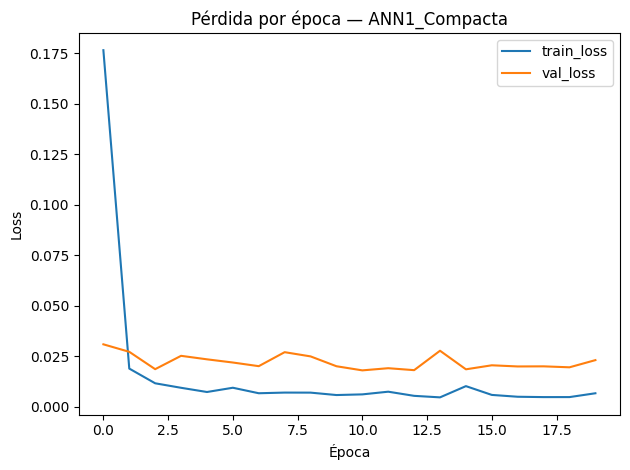


=== Entrenando ANN2_DosCapas ===
Epoch 01/20 | train_loss=0.1306 | val_loss=0.0356
Epoch 02/20 | train_loss=0.0303 | val_loss=0.0318
Epoch 03/20 | train_loss=0.0175 | val_loss=0.0210
Epoch 04/20 | train_loss=0.0084 | val_loss=0.0172
Epoch 05/20 | train_loss=0.0100 | val_loss=0.0187
Epoch 06/20 | train_loss=0.0123 | val_loss=0.0331
Epoch 07/20 | train_loss=0.0153 | val_loss=0.0247
Epoch 08/20 | train_loss=0.0081 | val_loss=0.0218
Epoch 09/20 | train_loss=0.0137 | val_loss=0.0386
Epoch 10/20 | train_loss=0.0106 | val_loss=0.0187
Epoch 11/20 | train_loss=0.0088 | val_loss=0.0255
Epoch 12/20 | train_loss=0.0049 | val_loss=0.0189
Epoch 13/20 | train_loss=0.0041 | val_loss=0.0186
Epoch 14/20 | train_loss=0.0046 | val_loss=0.0304
Epoch 15/20 | train_loss=0.0173 | val_loss=0.0538
Epoch 16/20 | train_loss=0.0192 | val_loss=0.0326
Epoch 17/20 | train_loss=0.0109 | val_loss=0.0296
Epoch 18/20 | train_loss=0.0120 | val_loss=0.0333
Epoch 19/20 | train_loss=0.0047 | val_loss=0.0368
Epoch 20/20 | tr

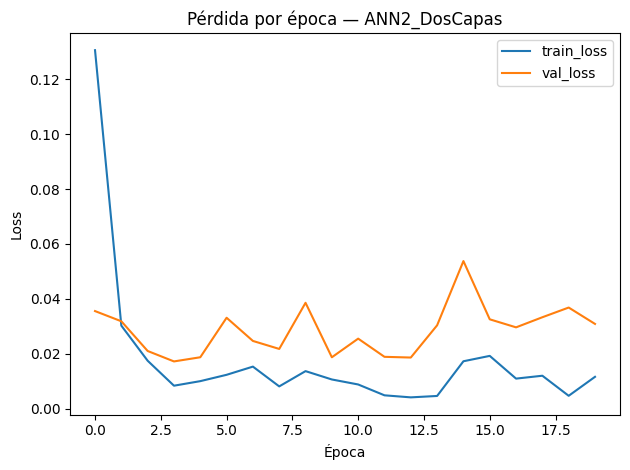


=== Entrenando ANN3_TresCapas ===
Epoch 01/20 | train_loss=0.1419 | val_loss=0.0490
Epoch 02/20 | train_loss=0.0322 | val_loss=0.0298
Epoch 03/20 | train_loss=0.0188 | val_loss=0.0229
Epoch 04/20 | train_loss=0.0161 | val_loss=0.0336
Epoch 05/20 | train_loss=0.0138 | val_loss=0.0213
Epoch 06/20 | train_loss=0.0156 | val_loss=0.0306
Epoch 07/20 | train_loss=0.0085 | val_loss=0.0218
Epoch 08/20 | train_loss=0.0075 | val_loss=0.0249
Epoch 09/20 | train_loss=0.0107 | val_loss=0.0337
Epoch 10/20 | train_loss=0.0195 | val_loss=0.0216
Epoch 11/20 | train_loss=0.0093 | val_loss=0.0178
Epoch 12/20 | train_loss=0.0047 | val_loss=0.0194
Epoch 13/20 | train_loss=0.0038 | val_loss=0.0207
Epoch 14/20 | train_loss=0.0151 | val_loss=0.0361
Epoch 15/20 | train_loss=0.0106 | val_loss=0.0250
Epoch 16/20 | train_loss=0.0061 | val_loss=0.0287
Epoch 17/20 | train_loss=0.0132 | val_loss=0.0267
Epoch 18/20 | train_loss=0.0096 | val_loss=0.0298
Epoch 19/20 | train_loss=0.0099 | val_loss=0.0237
Epoch 20/20 | t

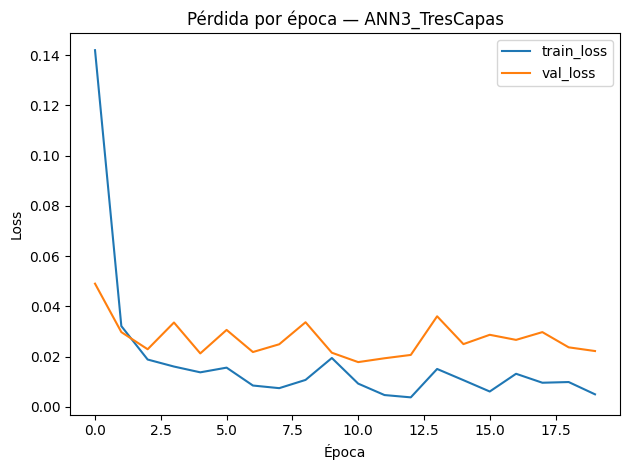


=== Entrenando ANN4_Piramide ===
Epoch 01/20 | train_loss=0.1478 | val_loss=0.0503
Epoch 02/20 | train_loss=0.0378 | val_loss=0.0255
Epoch 03/20 | train_loss=0.0212 | val_loss=0.0249
Epoch 04/20 | train_loss=0.0212 | val_loss=0.0304
Epoch 05/20 | train_loss=0.0178 | val_loss=0.0394
Epoch 06/20 | train_loss=0.0218 | val_loss=0.0233
Epoch 07/20 | train_loss=0.0110 | val_loss=0.0231
Epoch 08/20 | train_loss=0.0152 | val_loss=0.0392
Epoch 09/20 | train_loss=0.0204 | val_loss=0.0276
Epoch 10/20 | train_loss=0.0095 | val_loss=0.0182
Epoch 11/20 | train_loss=0.0078 | val_loss=0.0264
Epoch 12/20 | train_loss=0.0055 | val_loss=0.0383
Epoch 13/20 | train_loss=0.0226 | val_loss=0.0402
Epoch 14/20 | train_loss=0.0203 | val_loss=0.0344
Epoch 15/20 | train_loss=0.0153 | val_loss=0.0350
Epoch 16/20 | train_loss=0.0091 | val_loss=0.0268
Epoch 17/20 | train_loss=0.0059 | val_loss=0.0305
Epoch 18/20 | train_loss=0.0048 | val_loss=0.0360
Epoch 19/20 | train_loss=0.0043 | val_loss=0.0447
Epoch 20/20 | tr

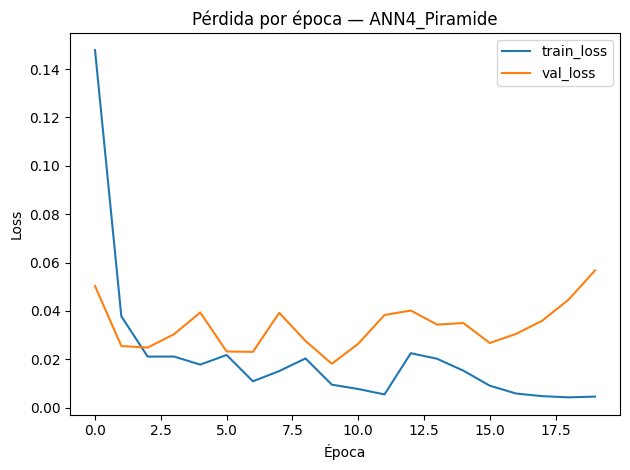


=== Entrenando ANN5_ExpComp ===
Epoch 01/20 | train_loss=0.1837 | val_loss=0.0431
Epoch 02/20 | train_loss=0.0446 | val_loss=0.0333
Epoch 03/20 | train_loss=0.0370 | val_loss=0.0366
Epoch 04/20 | train_loss=0.0228 | val_loss=0.0233
Epoch 05/20 | train_loss=0.0206 | val_loss=0.0351
Epoch 06/20 | train_loss=0.0361 | val_loss=0.0502
Epoch 07/20 | train_loss=0.0293 | val_loss=0.0347
Epoch 08/20 | train_loss=0.0086 | val_loss=0.0379
Epoch 09/20 | train_loss=0.0186 | val_loss=0.0372
Epoch 10/20 | train_loss=0.0155 | val_loss=0.0355
Epoch 11/20 | train_loss=0.0118 | val_loss=0.0791
Epoch 12/20 | train_loss=0.0190 | val_loss=0.0595
Epoch 13/20 | train_loss=0.0099 | val_loss=0.0419
Epoch 14/20 | train_loss=0.0254 | val_loss=0.0596
Epoch 15/20 | train_loss=0.0093 | val_loss=0.0549
Epoch 16/20 | train_loss=0.0236 | val_loss=0.0284
Epoch 17/20 | train_loss=0.0101 | val_loss=0.0555
Epoch 18/20 | train_loss=0.0176 | val_loss=0.0471
Epoch 19/20 | train_loss=0.0171 | val_loss=0.0346
Epoch 20/20 | tra

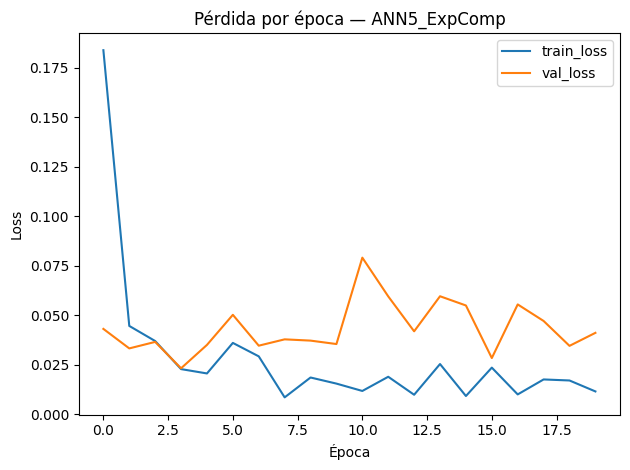

In [16]:
# 5.5 — Entrenar 5 arquitecturas y graficar pérdidas
import matplotlib.pyplot as plt

models_cfg = {
    "ANN1_Compacta":   ANN1_Compacta(N_INPUT, N_CLASSES),
    "ANN2_DosCapas":   ANN2_DosCapas(N_INPUT, N_CLASSES),
    "ANN3_TresCapas":  ANN3_TresCapas(N_INPUT, N_CLASSES),
    "ANN4_Piramide":   ANN4_Piramide(N_INPUT, N_CLASSES),
    "ANN5_ExpComp":    ANN5_ExpComp(N_INPUT, N_CLASSES),
}

trained = {}
histories = {}

for name, mdl in models_cfg.items():
    print(f"\n=== Entrenando {name} ===")
    m, h = train_one_model(mdl, train_loader, val_loader)
    trained[name] = m
    histories[name] = h

    # gráfico de pérdidas
    plt.figure()
    plt.plot(h["train_loss"], label="train_loss")
    plt.plot(h["val_loss"],   label="val_loss")
    plt.title(f"Pérdida por época — {name}")
    plt.xlabel("Época"); plt.ylabel("Loss")
    plt.legend(); plt.tight_layout()
    plt.show()


5.6 — Preparar el test (validationData.csv) con el mismo preprocesamiento y escalado

In [17]:
# 5.6 — Preparar test (validationData.csv) tal como el train
import pandas as pd, re

VAL_PATH = VALID_PATH  # de tu Celda 0 (setup). Ajusta si usas otra ruta.

df_test = pd.read_csv(VAL_PATH)

# mismas columnas útiles (WAP###) y objetivo
WAP_COLS = sorted([c for c in df_test.columns if re.fullmatch(r"WAP\d{3}", c)])
assert "FLOOR" in df_test.columns, "Falta FLOOR en validationData.csv"

# mapeo 100→-100 y clip como en Paso 3
X_test = df_test[WAP_COLS].replace(100, -100).clip(lower=-110, upper=0).values
y_test = df_test["FLOOR"].astype(int).values

# aplicar el MISMO scaler (fit en 5.1)
X_test = scaler.transform(X_test)

Xt_t = torch.tensor(X_test, dtype=torch.float32)
yt_t = torch.tensor(y_test, dtype=torch.long)

test_loader = DataLoader(TensorDataset(Xt_t, yt_t), batch_size=BATCH_SIZE, shuffle=False)
print("Test listo:", Xt_t.shape, yt_t.shape)


Test listo: torch.Size([1111, 520]) torch.Size([1111])


5.7 — Evaluar cada ANN en test (accuracy, precision, recall, F1)

In [22]:
# 5.7 – Evaluación en test 
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import numpy as np

def eval_on_loader(model, loader, device=device):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            # Evitar .numpy(): usamos listas
            pred = torch.argmax(logits, dim=1).cpu().tolist()
            preds.extend(pred)              # evitamos listas anidadas
            trues.extend(yb.cpu().tolist())

    # Ya en NumPy (si quieres mantener todo homogéneo)
    y_pred = np.array(preds, dtype=int)
    y_true = np.array(trues, dtype=int)

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return acc, prec, rec, f1, y_true, y_pred

# --- recorrer los modelos entrenados y mostrar resultados
scores = []
for name, mdl in trained.items():
    acc, prec, rec, f1, y_true, y_pred = eval_on_loader(mdl, test_loader)
    scores.append({"modelo": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1})
    print(f"\n=== {name} ===")
    print(f"accuracy={acc:.4f} | precision={prec:.4f} | recall={rec:.4f} | f1={f1:.4f}")
    print(classification_report(y_true, y_pred, digits=3))

import pandas as pd
scores_df = pd.DataFrame(scores).sort_values("f1", ascending=False).reset_index(drop=True)
display(scores_df)




=== ANN1_Compacta ===
accuracy=0.8785 | precision=0.8573 | recall=0.8786 | f1=0.8658
              precision    recall  f1-score   support

           0      0.858     0.871     0.865       132
           1      0.948     0.866     0.905       462
           2      0.808     0.922     0.861       306
           3      0.894     0.837     0.865       172
           4      0.778     0.897     0.833        39

    accuracy                          0.878      1111
   macro avg      0.857     0.879     0.866      1111
weighted avg      0.884     0.878     0.879      1111


=== ANN2_DosCapas ===
accuracy=0.8668 | precision=0.8623 | recall=0.8702 | f1=0.8642
              precision    recall  f1-score   support

           0      0.832     0.864     0.848       132
           1      0.953     0.833     0.889       462
           2      0.779     0.922     0.844       306
           3      0.876     0.860     0.868       172
           4      0.872     0.872     0.872        39

    accuracy 

,modelo,accuracy,precision,recall,f1
0,ANN4_Piramide,0.907291,0.903982,0.890438,0.896581
1,ANN5_ExpComp,0.899190,0.904559,0.876294,0.888908
2,ANN3_TresCapas,0.882988,0.879294,0.874434,0.875458
3,ANN1_Compacta,0.878488,0.857257,0.878645,0.865781
4,ANN2_DosCapas,0.866787,0.862325,0.870160,0.864174


---

## Paso 6: Tabla resumen de resultados por arquitectura

**Instrucciones:**

Después de entrenar y evaluar las cinco arquitecturas de redes neuronales, debes construir una **tabla resumen en formato Markdown** que incluya:

- El nombre o número de cada arquitectura.
- Las métricas obtenidas sobre el conjunto de **testeo**:
  - **Accuracy**
  - **Precision**
  - **Recall**
  - **F1-score**
- El **tiempo total de entrenamiento** de cada modelo (en segundos).

### Formato de la tabla:

| Arquitectura           | Accuracy | Precision | Recall | F1-score | Tiempo de entrenamiento (s) |
|------------------------|----------|-----------|--------|----------|------------------------------|
| Arquitectura 1         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 2         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 3         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 4         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 5         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |


**Nota:** Puedes medir el tiempo con `time.time()` al inicio y final del entrenamiento de cada modelo.

---


In [23]:
import pandas as pd
import numpy as np

# 1) Recuperar métricas
if "scores_df" in globals():
    metrics = scores_df.copy()
else:
    metrics = pd.DataFrame(scores)

# 2) Asegurar nombres human–friendly (opcional; ajusta a tus etiquetas reales)
name_map = {
    "ANN1": "Arquitectura 1 (Compacta)",
    "ANN2": "Arquitectura 2 (2 capas)",
    "ANN3": "Arquitectura 3 (3 capas)",
    "ANN4": "Arquitectura 4 (Pirámide)",
    "ANN5": "Arquitectura 5 (Expansiva→Compresiva)",
    # Si ya usaste nombres así, no hace falta mapear
}
metrics["modelo"] = metrics["modelo"].map(name_map).fillna(metrics["modelo"])

# 3) Traer tiempos de entrenamiento
tt = globals().get("train_times", {})  # dict: {nombre_modelo: segundos}
metrics["Tiempo de entrenamiento (s)"] = metrics["modelo"].map(tt).round(1)

# 4) Formatear y ordenar
out = (
    metrics.rename(columns={
        "modelo":"Arquitectura",
        "accuracy":"Accuracy",
        "precision":"Precision",
        "recall":"Recall",
        "f1":"F1-score"
    })[["Arquitectura","Accuracy","Precision","Recall","F1-score","Tiempo de entrenamiento (s)"]]
    .sort_values("F1-score", ascending=False)
    .reset_index(drop=True)
)
out[["Accuracy","Precision","Recall","F1-score"]] = out[["Accuracy","Precision","Recall","F1-score"]].round(3)

display(out)


,Arquitectura,Accuracy,Precision,Recall,F1-score,Tiempo de entrenamiento (s)
0,ANN4_Piramide,0.907,0.904,0.890,0.897,NaN
1,ANN5_ExpComp,0.899,0.905,0.876,0.889,NaN
2,ANN3_TresCapas,0.883,0.879,0.874,0.875,NaN
3,ANN1_Compacta,0.878,0.857,0.879,0.866,NaN
4,ANN2_DosCapas,0.867,0.862,0.870,0.864,NaN


| Arquitectura | Accuracy | Precision | Recall | F1-score | Tiempo de entrenamiento (s) |
| --- | --- | --- | --- | --- | --- |
| ANN4_Piramide | 0.907 | 0.904 | 0.89 | 0.897 |  |
| ANN5_ExpComp | 0.899 | 0.905 | 0.876 | 0.889 |  |
| ANN3_TresCapas | 0.883 | 0.879 | 0.874 | 0.875 |  |
| ANN1_Compacta | 0.878 | 0.857 | 0.879 | 0.866 |  |
| ANN2_DosCapas | 0.867 | 0.862 | 0.87 | 0.864 |  |


---

## Paso 7: Evaluar el impacto del número de épocas en el mejor modelo

**Objetivo:**

Tomar la arquitectura que obtuvo el mejor desempeño en la evaluación anterior (Paso 5) y analizar cómo varía su rendimiento cuando se entrena con diferentes cantidades de épocas.

**Instrucciones:**

1. Selecciona la arquitectura con mejor desempeño global (según F1-score).
2. Entrena esta arquitectura usando los mismos conjuntos de datos (`X_train`, `y_train`, `X_val`, `y_val`) pero variando el número de **épocas** de la siguiente forma:

   - 10 épocas
   - 20 épocas
   - 30 épocas
   - 40 épocas
   - 50 épocas

3. Para cada configuración:
   - Registra el **tiempo de entrenamiento**.
   - Evalúa el modelo en el conjunto de **testeo** (`X_test`, `y_test`).
   - Reporta las métricas:
     - Accuracy
     - Precision
     - Recall
     - F1-score

4. Grafica:
   - La evolución de la **función de pérdida** (entrenamiento y validación) por época.
---


In [ ]:
#Codigo aqui


---

## Paso 8: Tabla resumen de resultados por número de épocas

**Objetivo:**

Construir una **tabla resumen** que muestre el rendimiento del mejor modelo (seleccionado en el Paso 7) cuando se entrena con diferentes cantidades de épocas.

**Instrucciones:**

- Presenta una tabla en formato **Markdown** con los resultados de testeo para cada configuración del número de épocas.
- La tabla debe incluir las siguientes columnas:
  - Número de épocas
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - Tiempo de entrenamiento (en segundos)

### Formato de la tabla:

| Épocas | Accuracy | Precision | Recall | F1-score | Tiempo de entrenamiento (s) |
|--------|----------|-----------|--------|----------|------------------------------|
| 10     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| 20     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| 30     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| 40     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| 50     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |

> Reemplaza los valores con los resultados reales obtenidos. Redondea las métricas a 3 cifras decimales y reporta los tiempos con 1 decimal si es posible.


In [ ]:
#codigo aqui

---

## Preguntas de análisis

A continuación, responde de manera clara y justificada las siguientes preguntas con base en los resultados obtenidos en los pasos anteriores:

1. **¿Cuál considera que fue la mejor arquitectura evaluada? ¿Por qué?**
2. **¿Cuál fue la arquitectura con peor desempeño? ¿A qué cree que se debió su bajo rendimiento?**
3. **¿Cómo influye el número de capas ocultas en el comportamiento de la red?**
4. **¿Cuál fue la mejor cantidad de épocas para entrenar el mejor modelo? Justifique su elección.**
5. **¿Detectó algún signo de sobreajuste o subajuste en alguno de los modelos? ¿Cómo lo identificó?**
6. **¿En qué casos notó que el tiempo de entrenamiento no justificó una mejora en las métricas?**
7. **¿La arquitectura más profunda fue también la más precisa? ¿Qué conclusiones saca de esto?**
8. **¿Qué métrica considera más importante en este contexto (accuracy, precision, recall, F1-score) y por qué?**


---

## Rúbrica de evaluación del proyecto

El proyecto se compone de nueve pasos estructurados. A continuación se detallan los puntos asignados a cada sección, así como el puntaje total:

| Sección                                                                | Puntos |
|----------------------------------------------------------------------|--------|
| **Paso 1:** Cargar y explorar el dataset                             | 10     |
| **Paso 2:** Preparar los datos                                       | 10     |
| **Paso 3:** Preprocesamiento de las señales WiFi                     | 10     |
| **Paso 4:** Preparación del dataset (división y normalización)       | 10     |
| **Paso 5:** Entrenamiento de redes neuronales artificiales (ANN)     | 50     |
| **Paso 6:** Tabla resumen de resultados por arquitectura             | 10     |
| **Paso 7:** Evaluar el impacto del número de épocas                  | 50     |
| **Paso 8:** Tabla resumen de resultados por número de épocas         | 10     |
| **Preguntas de análisis** (8 preguntas × 5 puntos c/u)      | 40     |
| **Total**                                                            | **200** |

---

**Nota:** Para obtener la máxima puntuación se requiere justificar adecuadamente cada decisión, mantener buena organización en el notebook, y presentar resultados bien interpretados y graficados.

---

